#  NumPy and Matplotlib News Analysis

This notebook performs deep statistical analysis on the news headlines dataset. Beyond simple counts, we explore structural characteristics of global news reporting using **NumPy** for numerical computation and **Matplotlib** for premium visualization.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('bmh')
sns.set_palette('viridis')

# Load the dataset
df = pd.read_csv("news_data.csv")
df_clean = df.dropna(subset=['source', 'title', 'description']).copy()
print(f"Loaded {len(df_clean)} high-quality news entries.")

Loaded 486 high-quality news entries.


## 1. Source Volume Distribution
Which publishers are dominating the current feed?

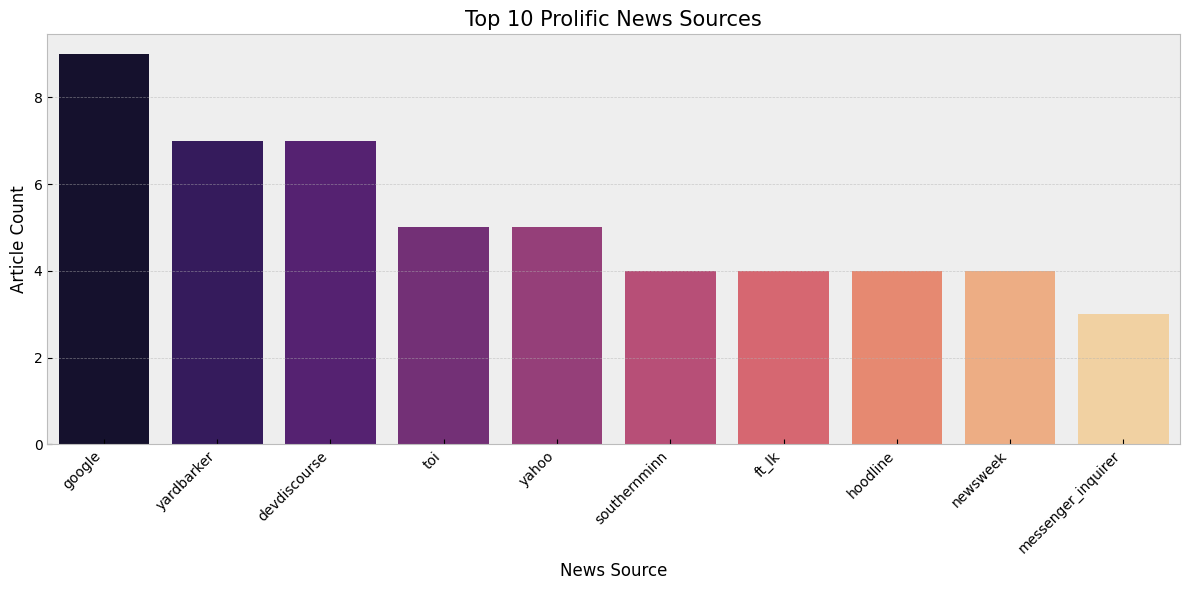

In [10]:
source_counts = df_clean["source"].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='magma', hue=source_counts.index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Prolific News Sources", fontsize=15)
plt.xlabel("News Source", fontsize=12)
plt.ylabel("Article Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Headlines Structural Analysis (NumPy Power)
We use NumPy to calculate the statistical distribution of headline lengths (character count).

--- Statistical Summary of Title Lengths ---
Mean Length:   79.33 chars
Median Length: 74.50 chars
Std Deviation: 25.60 chars
Max Length:    234 chars


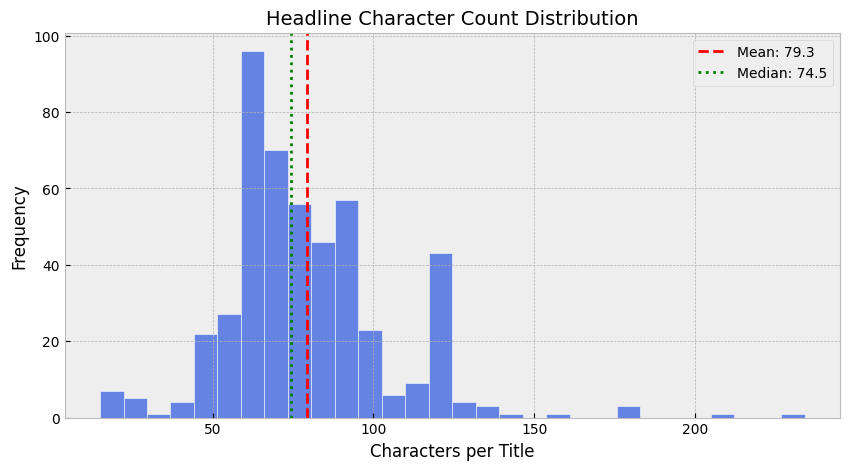

In [11]:
# Vectorized operation to get lengths
title_lengths = np.array([len(str(t)) for t in df_clean['title']])

mean_len = np.mean(title_lengths)
median_len = np.median(title_lengths)
std_len = np.std(title_lengths)

print(f"--- Statistical Summary of Title Lengths ---")
print(f"Mean Length:   {mean_len:.2f} chars")
print(f"Median Length: {median_len:.2f} chars")
print(f"Std Deviation: {std_len:.2f} chars")
print(f"Max Length:    {np.max(title_lengths)} chars")

plt.figure(figsize=(10, 5))
plt.hist(title_lengths, bins=30, color='royalblue', edgecolor='white', alpha=0.8)
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_len:.1f}')
plt.title("Headline Character Count Distribution", fontsize=14)
plt.xlabel("Characters per Title")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 3. Description Verbosity (Word Count)
Analysis of how descriptive news articles are across the dataset.

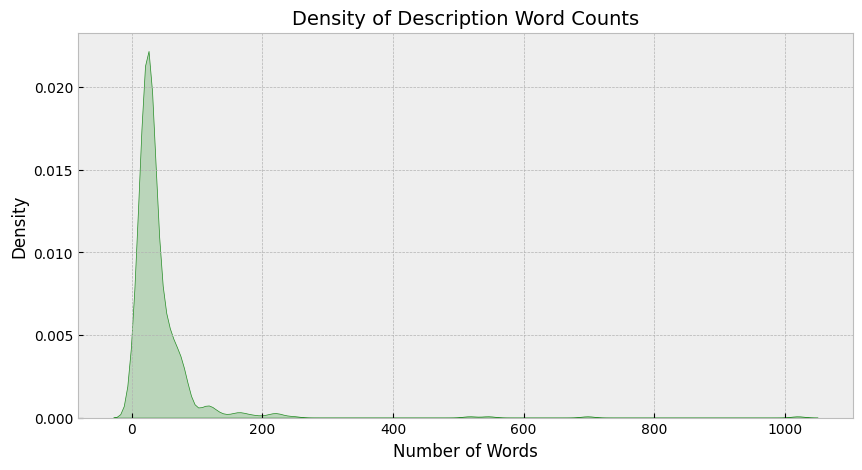

Average words per description: 43.0


In [12]:
# Use NumPy to split and count words
desc_word_counts = np.array([len(str(d).split()) for d in df_clean['description']])

plt.figure(figsize=(10, 5))
sns.kdeplot(desc_word_counts, fill=True, color="forestgreen", bw_adjust=0.5)
plt.title("Density of Description Word Counts", fontsize=14)
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.show()

print(f"Average words per description: {np.mean(desc_word_counts):.1f}")

## 4. Complexity Benchmark
Correlation between Headline length and Description length to see if 'wordy' headlines lead to 'wordy' descriptions.

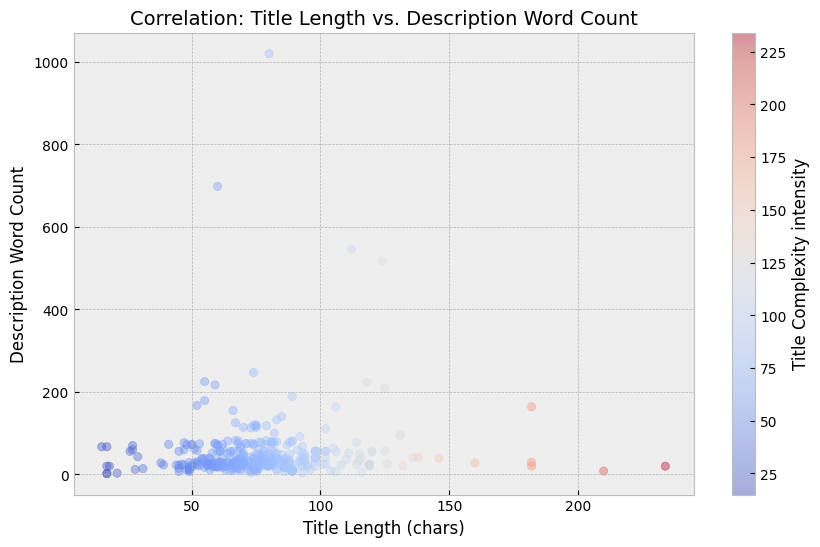

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(title_lengths, desc_word_counts, alpha=0.4, c=title_lengths, cmap='coolwarm')
plt.title("Correlation: Title Length vs. Description Word Count", fontsize=14)
plt.xlabel("Title Length (chars)")
plt.ylabel("Description Word Count")
plt.colorbar(label='Title Complexity intensity')
plt.show()